### EDA cont.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [17]:
da = pd.read_csv('cleaned_school_data_updated.csv')

In [18]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14467 entries, 0 to 14466
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Report Category       14467 non-null  object 
 1   DBN                   14467 non-null  object 
 2   school_name           14467 non-null  object 
 3   Grade                 14467 non-null  object 
 4   Year                  14467 non-null  int64  
 5   Student Category      14467 non-null  object 
 6   number_tested         14467 non-null  int64  
 7   mean_scale_score      14389 non-null  float64
 8   level_1_count         14389 non-null  float64
 9   level_1_percentage    14389 non-null  float64
 10  level_2_count         14389 non-null  float64
 11  level_2_percentage    14389 non-null  float64
 12  level_3_count         14389 non-null  float64
 13  level_3_percentage    14389 non-null  float64
 14  level_4_count         14389 non-null  float64
 15  level_4_percentage 

In [19]:
da_clean = da.dropna(subset=['% Poverty', 'mean_scale_score'])

In [20]:
da_clean['School Level'] = da_clean['Grade'].apply(lambda x: 'Elementary' if x in ['3','4','5'] else 'Middle')

C:\Users\madis\AppData\Local\Temp\ipykernel_42172\241498269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_clean['School Level'] = da_clean['Grade'].apply(lambda x: 'Elementary' if x in ['3','4','5'] else 'Middle')


In [21]:
da_clean = da_clean[da_clean['Grade'] != 'All Grades']


In [24]:
da_clean['poverty_clean'] = da_clean['% Poverty'] * 100

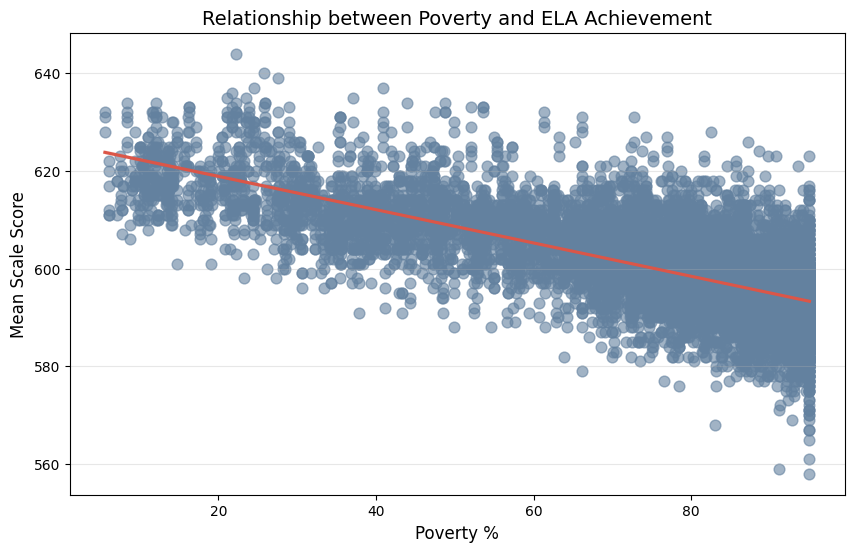

In [25]:



plt.figure(figsize=(10, 6))

sns.regplot(data=da_clean, x='poverty_clean', y='mean_scale_score',
            scatter_kws={'color': "#63819f", 'alpha': 0.6, 's': 60},
            line_kws={'color': "#db5648"})


plt.title('Relationship between Poverty and ELA Achievement', fontsize=14)
plt.xlabel('Poverty %', fontsize=12)
plt.ylabel('Mean Scale Score', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [26]:
da_clean

,Report Category,DBN,school_name,Grade,Year,Student Category,number_tested,mean_scale_score,level_1_count,level_1_percentage,...,level_3_count,level_3_percentage,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty,Poverty_Category,School Level,poverty_clean
0,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2022,All Students,21,594.0,4.0,19.0,...,4.0,19.0,1.0,4.8,5.0,23.8,0.838,1,Elementary,83.8
1,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2022,All Students,30,596.0,6.0,20.0,...,5.0,16.7,5.0,16.7,10.0,33.3,0.838,1,Elementary,83.8
2,School,01M015,P.S. 015 ROBERTO CLEMENTE,5,2022,All Students,23,599.0,11.0,47.8,...,4.0,17.4,4.0,17.4,8.0,34.8,0.838,1,Elementary,83.8
4,School,01M015,P.S. 015 ROBERTO CLEMENTE,3,2019,All Students,27,606.0,1.0,3.7,...,18.0,66.7,1.0,3.7,19.0,70.4,0.845,1,Elementary,84.5
5,School,01M015,P.S. 015 ROBERTO CLEMENTE,4,2019,All Students,18,607.0,0.0,0.0,...,11.0,61.1,3.0,16.7,14.0,77.8,0.845,1,Elementary,84.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2019,All Students,109,595.0,42.0,38.5,...,26.0,23.9,6.0,5.5,32.0,29.4,0.949,1,Middle,94.9
14461,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,8,2019,All Students,109,596.0,16.0,14.7,...,28.0,25.7,8.0,7.3,36.0,33.0,0.949,1,Middle,94.9
14463,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,6,2018,All Students,111,595.0,37.0,33.3,...,26.0,23.4,11.0,9.9,37.0,33.3,0.915,1,Middle,91.5
14464,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,7,2018,All Students,116,592.0,50.0,43.1,...,18.0,15.5,0.0,0.0,18.0,15.5,0.915,1,Middle,91.5


C:\Users\madis\AppData\Local\Temp\ipykernel_42172\3739747372.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Year', 'poverty_quartile'])['mean_scale_score']


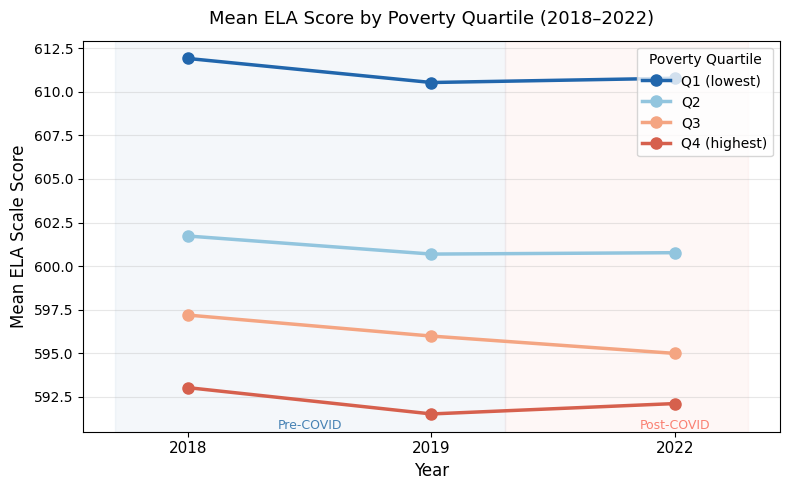

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Create poverty quartiles
da_clean['poverty_quartile'] = pd.qcut(
    da_clean['% Poverty'],
    q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)

# Mean score by year and quartile
trends = (
    da_clean
    .groupby(['Year', 'poverty_quartile'])['mean_scale_score']
    .mean()
    .unstack('poverty_quartile')
    .sort_index()
    .reset_index()
)

x = [0, 1, 2]
year_labels = ['2018', '2019', '2022']
colors = ['#2166ac', '#92c5de', '#f4a582', '#d6604d']

fig, ax = plt.subplots(figsize=(8, 5))

for col, color in zip(trends.columns[1:], colors):
    ax.plot(x, trends[col], marker='o', linewidth=2.5, markersize=8,
            color=color, label=col)

ax.axvspan(-0.3, 1.3, alpha=0.06, color='steelblue')
ax.axvspan(1.3, 2.3, alpha=0.06, color='salmon')
ax.text(0.5, ax.get_ylim()[0], 'Pre-COVID', ha='center', color='steelblue', fontsize=9, va='bottom')
ax.text(2.0, ax.get_ylim()[0], 'Post-COVID', ha='center', color='salmon', fontsize=9, va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(year_labels, fontsize=11)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean ELA Scale Score', fontsize=12)
ax.set_title('Mean ELA Score by Poverty Quartile (2018–2022)', fontsize=13, pad=12)
ax.legend(title='Poverty Quartile', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()